# Data Preprocessing — Amazon Reviews
Simple, linear notebook: load → explore → clean → label → balance → save.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

#sns.set_style('whitegrid')

## 2. Load the data

In [2]:
RAW_CSV_PATH = "../data/processed/combined_data.csv"
df = pd.read_csv(RAW_CSV_PATH)
print(df.shape)
df.head()

(30744, 8)


,asins,categories,id,name,primaryCategories,reviews.rating,reviews.text,reviews.title
0,"B00QWO9P0O,B00LH3DMUO","AA,AAA,Health,Electronics,Health & Household,C...",AVpgNzjwLJeJML43Kpxn,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,3,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...
1,"B00QWO9P0O,B00LH3DMUO","AA,AAA,Health,Electronics,Health & Household,C...",AVpgNzjwLJeJML43Kpxn,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,4,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...
2,"B00QWO9P0O,B00LH3DMUO","AA,AAA,Health,Electronics,Health & Household,C...",AVpgNzjwLJeJML43Kpxn,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,5,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...
3,"B00QWO9P0O,B00LH3DMUO","AA,AAA,Health,Electronics,Health & Household,C...",AVpgNzjwLJeJML43Kpxn,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,5,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...
4,"B00QWO9P0O,B00LH3DMUO","AA,AAA,Health,Electronics,Health & Household,C...",AVpgNzjwLJeJML43Kpxn,AmazonBasics AAA Performance Alkaline Batterie...,Health & Beauty,5,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...


## 3. Explore the data (EDA)


In [3]:
df.columns.tolist()

['asins',
 'categories',
 'id',
 'name',
 'primaryCategories',
 'reviews.rating',
 'reviews.text',
 'reviews.title']

In [4]:
TEXT_COL = "reviews.text"     # column containing the review text
RATING_COL = "reviews.rating"      # column containing the 1-5 star rating

df[[TEXT_COL, RATING_COL]].head()

,reviews.text,reviews.rating
0,I order 3 of them and one of the item is bad q...,3
1,Bulk is always the less expensive way to go fo...,4
2,Well they are not Duracell but for the price i...,5
3,Seem to work as well as name brand batteries a...,5
4,These batteries are very long lasting the pric...,5


In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nRating counts:")
print(df[RATING_COL].value_counts())

Missing values:
asins                 0
categories            0
id                    0
name                  0
primaryCategories     0
reviews.rating        0
reviews.text          0
reviews.title        11
dtype: int64

Rating counts:
reviews.rating
5    21356
4     6406
3     1329
1     1001
2      652
Name: count, dtype: int64


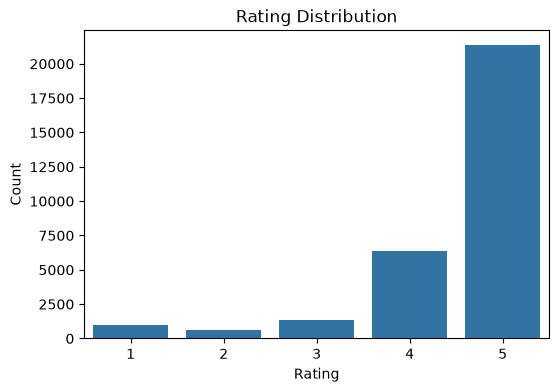

In [6]:
# Plot rating distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df[RATING_COL].astype(str), order=sorted(df[RATING_COL].astype(str).unique()))
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

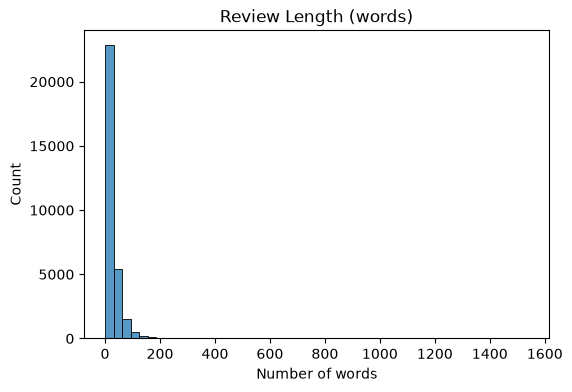

In [7]:
# Plot review length distribution (in words)
review_lengths = df[TEXT_COL].astype(str).str.split().apply(len)

plt.figure(figsize=(6,4))
sns.histplot(review_lengths, bins=50)
plt.title("Review Length (words)")
plt.xlabel("Number of words")
plt.show()

**Observation:** most Amazon reviews are 4-5 stars (~90% positive). We'll fix this imbalance further down using undersampling.

## 4. Clean the text
Basic cleaning only — lowercase, remove HTML/URLs, collapse whitespace. We keep it light because the transformer tokenizer (DistilBERT) will handle the rest later — removing stopwords or stemming would actually hurt its performance.

In [8]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)              # remove HTML tags
    text = re.sub(r"http\S+|www\.\S+", " ", text)   # remove URLs
    text = re.sub(r"[^a-z0-9\s.,!?'\"-]", " ", text) # keep basic punctuation only
    text = re.sub(r"\s+", " ", text).strip()        # collapse whitespace
    return text

#df = df.dropna(subset=[TEXT_COL, RATING_COL])
#df = df.drop_duplicates(subset=[TEXT_COL, RATING_COL])
df["clean_text"] = df[TEXT_COL].apply(clean_text)

# drop very short reviews (less than 3 words) — not useful signal
#df = df[df["clean_text"].str.split().apply(len) >= 3]
df = df.reset_index(drop=True)

print(df.shape)
df[["clean_text"]].head()

(30744, 9)


,clean_text
0,i order 3 of them and one of the item is bad q...
1,bulk is always the less expensive way to go fo...
2,well they are not duracell but for the price i...
3,seem to work as well as name brand batteries a...
4,these batteries are very long lasting the pric...


In [9]:
df[['reviews.text', 'reviews.title', 'reviews.rating', 'clean_text']]

,reviews.text,reviews.title,reviews.rating,clean_text
0,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,3,i order 3 of them and one of the item is bad q...
1,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,4,bulk is always the less expensive way to go fo...
2,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,5,well they are not duracell but for the price i...
3,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,5,seem to work as well as name brand batteries a...
4,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,5,these batteries are very long lasting the pric...
...,...,...,...,...
30739,This is a great tablet for the price. Amazon i...,Good product,5,this is a great tablet for the price. amazon i...
30740,This tablet is the perfect size and so easy to...,Great Tablet,5,this tablet is the perfect size and so easy to...
30741,Purchased this for my son. Has room to upgrade...,Great for kids or smaller needs,4,purchased this for my son. has room to upgrade...
30742,I had some thoughts about getting this for a 5...,Very sturdy for a 5 year old,5,i had some thoughts about getting this for a 5...


## 5. Create the sentiment label from the star rating
1-2 stars → negative, 3 stars → neutral, 4-5 stars → positive.

In [10]:
def rating_to_label(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df["label"] = df[RATING_COL].apply(rating_to_label)
df["label"].value_counts()

label
positive    27762
negative     1653
neutral      1329
Name: count, dtype: int64

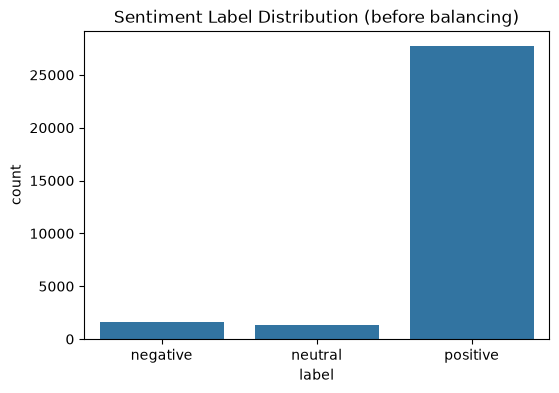

In [11]:
# Plot label distribution BEFORE balancing
plt.figure(figsize=(6,4))
sns.countplot(x=df["label"], order=["negative", "neutral", "positive"])
plt.title("Sentiment Label Distribution (before balancing)")
plt.show()

## 6. Save the cleaned (still imbalanced) dataset


In [16]:
df.isna().sum()

asins                 0
categories            0
id                    0
name                  0
primaryCategories     0
reviews.rating        0
reviews.text          0
reviews.title        11
clean_text            0
label                 0
dtype: int64

In [12]:
df.columns

Index(['asins', 'categories', 'id', 'name', 'primaryCategories',
       'reviews.rating', 'reviews.text', 'reviews.title', 'clean_text',
       'label'],
      dtype='str')

In [13]:
df.shape

(30744, 10)

In [15]:
df.to_csv("../data/processed/combined_cleaned_full.csv", index=False)
print("Saved:", df.shape)

Saved: (30744, 10)


## 7. Fix class imbalance with undersampling
Since ~90% of reviews are positive, we downsample every class to match the size of the smallest class (usually 'neutral'). This is plain pandas — no special function needed.

In [21]:
counts = df["label"].value_counts()
print("Before balancing:\n", counts)
print('Shape' , df.shape)

min_count = 3000#counts.min()

df_negative = df[df["label"] == "negative"]#.sample(n=min_count, random_state=42)
df_neutral  = df[df["label"] == "neutral"]#.sample(n=min_count, random_state=42)
df_positive = df[df["label"] == "positive"].sample(n=min_count, random_state=42)

df_balanced = pd.concat([df_negative, df_neutral, df_positive])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print("\nAfter balancing:\n", df_balanced["label"].value_counts())
print('Shape' , df_balanced.shape)

Before balancing:
 label
positive    27762
negative     1653
neutral      1329
Name: count, dtype: int64
Shape (30744, 10)

After balancing:
 label
positive    3000
negative    1653
neutral     1329
Name: count, dtype: int64
Shape (5982, 10)


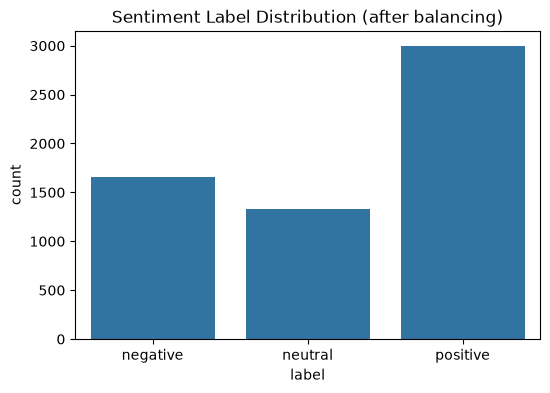

In [18]:
# Plot label distribution AFTER balancing
plt.figure(figsize=(6,4))
sns.countplot(x=df_balanced["label"], order=["negative", "neutral", "positive"])
plt.title("Sentiment Label Distribution (after balancing)")
plt.show()

## 8. Save the final balanced dataset
This is the file the training notebook will load next.

In [20]:
df_balanced.to_csv("../data/processed/reviews_balanced.csv", index=False)
print("Saved:", df_balanced.shape)
df_balanced.head()

Saved: (5982, 10)


,asins,categories,id,name,primaryCategories,reviews.rating,reviews.text,reviews.title,clean_text,label
0,"B00QWO9P0O,B01IB83NZG,B00MNV8E0C","AA,AAA,Electronics Features,Health,Electronics...",AVpe7xlELJeJML43ypLz,AmazonBasics AA Performance Alkaline Batteries...,Health & Beauty,1,Very little capacity. They last only about 25 ...,They don't last very long,very little capacity. they last only about 25 ...,negative
1,B01AHB9C1E,"Fire Tablets,Tablets,All Tablets,Amazon Tablet...",AVqkIj9snnc1JgDc3khU,"Fire HD 8 Tablet with Alexa, 8 HD Display, 32 ...",Electronics,5,my daughter just loved this kindle fire. she s...,great reader my dautgher loves it,my daughter just loved this kindle fire. she s...,positive
2,"B00QWO9P0O,B01IB83NZG,B00MNV8E0C","AA,AAA,Electronics Features,Health,Electronics...",AVpe7xlELJeJML43ypLz,AmazonBasics AA Performance Alkaline Batteries...,Health & Beauty,5,Amazon batteries are always a GREAT deal!,Five Stars,amazon batteries are always a great deal!,positive
3,B018Y22BI4,"Fire Tablets,Computers/Tablets & Networking,Ta...",AVpgdkC8ilAPnD_xsvyi,"Fire Tablet, 7 Display, Wi-Fi, 16 GB - Include...",Electronics,2,Amazon fire is a good tablet if you like e-boo...,Okay tablet,amazon fire is a good tablet if you like e-boo...,negative
4,B018T075DC,"Fire Tablets,Tablets,All Tablets,Amazon Tablet...",AVqkIhxunnc1JgDc3kg_,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",Electronics,5,Great tablet for my son. Live the endless libr...,Good tablet,great tablet for my son. live the endless libr...,positive


# Notes

- Performed EDA and cleaned review text
- View sentiment distribution - Extreme class imbalance found - more than 90% of the sentiments are positive
- Performed undersampling on positive class and then use class weights later while training model.